In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
mobile_sales = pd.read_csv('/content/drive/MyDrive/Time Series and Recsys data/time_series_2_data.csv')

In [ ]:
mobile_sales.head()

,DATE,Sales
0,2001-01-01,6802.44
1,2001-02-01,6802.44
2,2001-03-01,7332.00
3,2001-04-01,7332.00
4,2001-05-01,8240.00


In [ ]:
mobile_sales = mobile_sales.set_index('DATE')

In [ ]:
mobile_sales.index = pd.to_datetime(mobile_sales.index)

In [ ]:
mobile_sales

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2018-09-01,13838.00
2018-10-01,15351.00
2018-11-01,15615.00


In [ ]:
mobile_sales = mobile_sales.asfreq('MS')

<Axes: xlabel='DATE'>

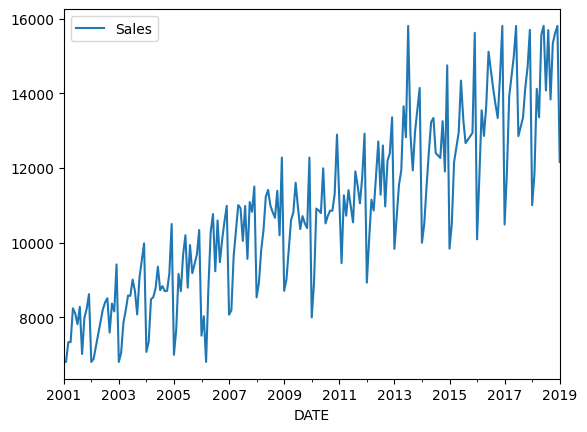

In [ ]:
mobile_sales.plot()

In [ ]:
import statsmodels.api as sm
decomposed = sm.tsa.seasonal_decompose(
    mobile_sales.Sales,
    model='additive',   # switch model
    period=12
)

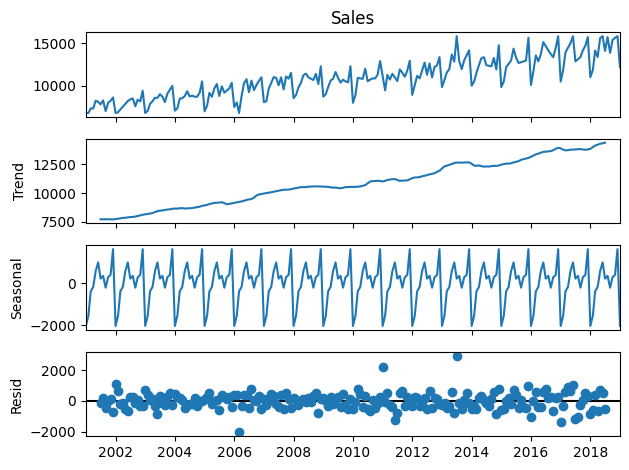

In [ ]:
decomposed.plot();

In [ ]:
decomposed = sm.tsa.seasonal_decompose(
    mobile_sales.Sales,
    model='additive',   # switch model
    period=12
)

In [ ]:
decomposed.trend.head(20)

,trend
DATE,
2001-01-01,NaN
2001-02-01,NaN
2001-03-01,NaN
2001-04-01,NaN
2001-05-01,NaN
2001-06-01,NaN
2001-07-01,7712.573333
2001-08-01,7715.888333
2001-09-01,7714.161667


In [ ]:
decomposed.seasonal.head(20)

,seasonal
DATE,
2001-01-01,-2032.037280
2001-02-01,-1541.160123
2001-03-01,-390.864633
2001-04-01,-182.669927
2001-05-01,562.026152
2001-06-01,977.197230
2001-07-01,211.346549
2001-08-01,342.453504
2001-09-01,-218.812574


In [ ]:
len(mobile_sales)

217

In [ ]:
train_x = mobile_sales.iloc[:193]
test_x = mobile_sales.iloc[193:]

In [ ]:
mobile_sales

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2018-09-01,13838.00
2018-10-01,15351.00
2018-11-01,15615.00


# We will not have y_train and y_test. Why?

In [ ]:
eval_df = test_x.copy()

In [ ]:
eval_df

,Sales
DATE,
2017-02-01,11891.0
2017-03-01,13921.0
2017-04-01,14453.5
2017-05-01,14986.0
2017-06-01,15809.4
2017-07-01,12856.0
2017-08-01,13102.5
2017-09-01,13349.0
2017-10-01,14150.0


In [ ]:
eval_df = test_x.copy()
eval_df['seasonal_naive_pred'] = mobile_sales.iloc[181:205]['Sales'].values

<Axes: xlabel='DATE'>

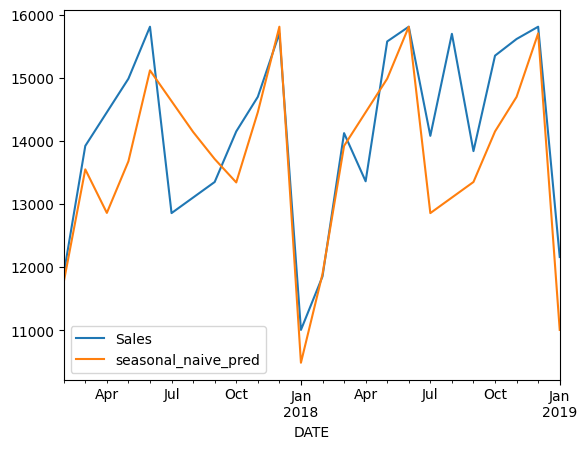

In [ ]:
eval_df.plot()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape

In [ ]:
mape(eval_df['Sales'],eval_df['seasonal_naive_pred'])

0.05477719691436225

In [ ]:
train_x['Sales'].iloc[0]

np.float64(6802.44)

In [ ]:
train_x['Sales'].iloc[-1]

np.float64(10485.0)

In [ ]:
train_x

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2016-09-01,13713.00
2016-10-01,13342.00
2016-11-01,14455.00


# Drift method

In [ ]:
drift = (train_x['Sales'].iloc[-1]-train_x['Sales'].iloc[0])/(len(train_x)-1)
last = train_x['Sales'].iloc[-1]
num_points = np.arange(1, 25)


In [ ]:
len(test_x)

24

In [ ]:
num_points

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [ ]:
last

np.float64(10485.0)

In [ ]:
num_points

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [ ]:
drift

np.float64(19.180000000000003)

In [ ]:
eval_df['drift_pred'] = last + num_points * drift

<Axes: xlabel='DATE'>

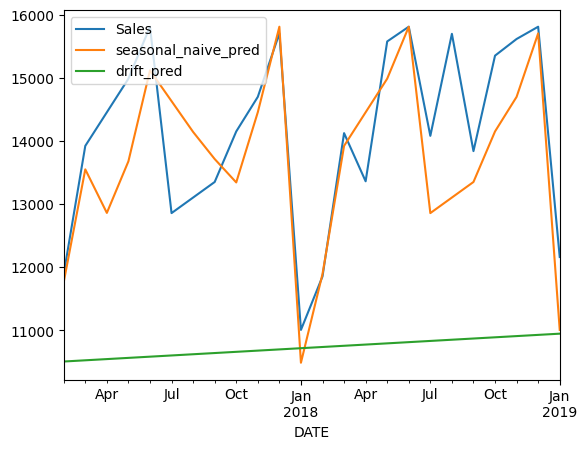

In [ ]:
eval_df.plot()

In [ ]:
mape(eval_df['Sales'],eval_df['drift_pred'])

0.23316721416408268

/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


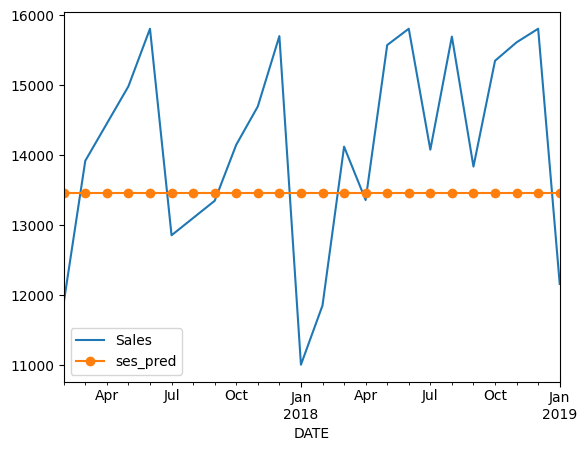

In [ ]:
model = sm.tsa.SimpleExpSmoothing(train_x).fit(smoothing_level=0.2)
pred = model.forecast(steps = 24)

test_x.plot(label='original')

pred.plot(label='ses_pred', style='-o')
plt.legend()

In [ ]:
eval_df['ses_pred'] = model.forecast(steps = 24)

In [ ]:
mape(eval_df['Sales'],eval_df['ses_pred'])

0.0945200784016444